# Algoritmo de análisis de imágenes para el control del robot

**Autores:** Lucia Fuentes González (210229), Tania Mobasser Aslfakouri (220299), Miriam Bernat Jiménez (210162)


## Imports y directorios

In [30]:
import os
import numpy as np
import cv2
import imageio.v3 as iio
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

# Carpetas de datos
DIR_ETIQ = os.path.join('..','images')
DIR_VIDEOS  = os.path.join('..','videos')

PATH_FRAME = os.path.join('..','images','001.png')
PATH_MARK  = os.path.join('..','images','001_mark.png')


## 1. Reutilización del segmentador del punto 1

Construimos un dataset de píxeles etiquetados pooled sobre los 5 frames etiquetados (no sólo el 001 que usamos en el punto 1) para tener un clasificador más robusto, y entrenamos el NearestCentroid de scikit-learn (tal como en la práctica de segmentación).


In [31]:
def normaliza_rg(im):
    im_float = im.astype(np.float64)
    suma = im_float.sum(axis=2, keepdims=True)
    suma[suma == 0] = 1.0
    return im_float / suma


def cargar_pixeles_frame(path_im=PATH_FRAME, path_mark=PATH_MARK):
    """Extrae píxeles etiquetados de un único frame (imagen + máscara de color)."""
    # Cargo las imágenes desde el path
    mk = iio.imread(path_mark)
    im = iio.imread(path_im)

    mk = mk[:, :, :3]
    mask_marca = (mk[:,:,0] == 255) & (mk[:,:,1] == 0) & (mk[:,:,2] == 0)   # rojo = marca
    mask_fondo = (mk[:,:,0] == 0) & (mk[:,:,1] == 255) & (mk[:,:,2] == 0)   # verde = fondo/suelo
    mask_linea = (mk[:,:,0] == 0) & (mk[:,:,1] == 0) & (mk[:,:,2] == 255)   # azul = linea

    # Normalizo la imagen
    imNorm = normaliza_rg(im)

    # Extraigo datos de cada región en espacio rg normalizado
    data_marca = imNorm[mask_marca]  # (N, 3)
    data_fondo = imNorm[mask_fondo]
    data_linea = imNorm[mask_linea]

    # Solo uso r y g normalizados (b = 1 - r - g, es redundante)
    X_marca = data_marca[:, :2]  # (N_marca, 2)
    X_fondo = data_fondo[:, :2]
    X_linea = data_linea[:, :2]

    # Etiquetas: 0=marca, 1=fondo, 2=línea
    y_marca = np.zeros(len(X_marca), dtype=int)
    y_fondo = np.ones(len(X_fondo), dtype=int)
    y_linea = np.full(len(X_linea), 2, dtype=int)

    # Concateno todo
    X = np.vstack([X_marca, X_fondo, X_linea])
    y = np.concatenate([y_marca, y_fondo, y_linea])

    return X, y

def cargar_pixeles_todos_frames(dir_etiq):
    """Pool de píxeles etiquetados de todos los frames *_mark.png en dir_etiq."""
    X_list, y_list = [], []
    for fname in os.listdir(dir_etiq):
        if fname.endswith('_mark.png'):
            path_mark = os.path.join(dir_etiq, fname)
            path_im = path_mark.replace('_mark.png', '.png')
            X, y = cargar_pixeles_frame(path_im, path_mark)
            X_list.append(X)
            y_list.append(y)
    return np.vstack(X_list), np.concatenate(y_list)

X, y = cargar_pixeles_todos_frames(DIR_ETIQ)

# Clasificador NearestCentroid de sklearn
clf = NearestCentroid()
clf.fit(X, y)

print('Tamaño dataset:', X.shape)
print('Centroides de cada clase (r_norm, g_norm):')
nombres_clase = ['marca', 'fondo', 'línea']
for i, nombre in enumerate(nombres_clase):
    print(f'  {nombre}: {clf.centroids_[i]}')


Tamaño dataset: (82543, 2)
Centroides de cada clase (r_norm, g_norm):
  marca: [0.49497286 0.28406798]
  fondo: [0.3396269  0.36875265]
  línea: [0.15409867 0.3276591 ]


In [32]:
def segmentar(im_rgb, clf):
    """Aplica el clasificador NearestCentroid de sklearn.
    Devuelve un mapa de etiquetas (H, W) con valores 0=marca, 1=fondo, 2=linea."""
    H, W, _ = im_rgb.shape
    im_norm = normaliza_rg(im_rgb)
    pixels = im_norm[:, :, :2].reshape(-1, 2)
    etiquetas = clf.predict(pixels)
    return etiquetas.reshape(H, W)

def segmentar_imagen(im_rgb, clf):
    """Versión visual de segmentar: devuelve una imagen RGB coloreada
    con 0=rojo(marca), 1=verde(fondo), 2=azul(linea)."""
    paleta = np.array([
        [255,   0,   0],   # 0 = marca (rojo)
        [  0, 255,   0],   # 1 = fondo (verde)
        [  0,   0, 255],   # 2 = linea (azul)
    ], dtype=np.uint8)
    H, W, _ = im_rgb.shape
    etiquetas = segmentar(im_rgb, clf)
    return paleta[etiquetas].reshape(H, W, 3)

def mascaras(etiquetas):
    """Devuelve mascaras booleanas (linea, marca)"""
    m_linea = (etiquetas == 2)
    m_marca = (etiquetas == 0)
    return m_linea, m_marca


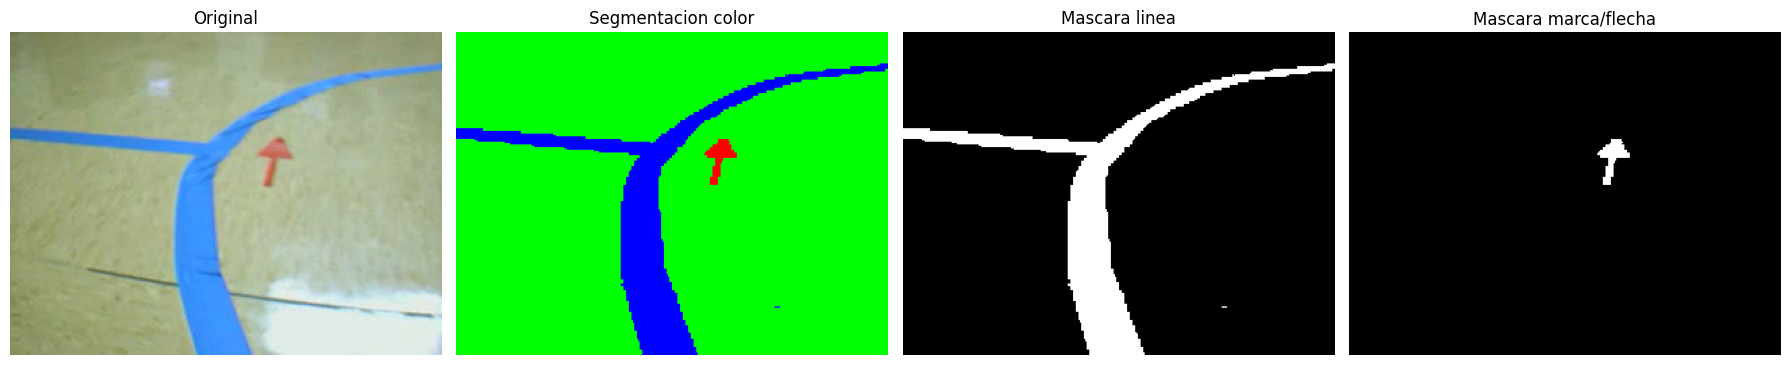

In [33]:
# Ejemplo con frame 001
im = iio.imread(os.path.join(DIR_ETIQ, '001.png'))[:, :, :3]
etiquetas = segmentar(im, clf)
m_linea, m_marca = mascaras(etiquetas)
im_seg = segmentar_imagen(im, clf)

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(im)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(im_seg)
axs[1].set_title('Segmentacion color')
axs[1].axis('off')
axs[2].imshow(m_linea, cmap='gray')
axs[2].set_title('Mascara linea')
axs[2].axis('off')
axs[3].imshow(m_marca, cmap='gray')
axs[3].set_title('Mascara marca/flecha')
axs[3].axis('off')
plt.tight_layout()
plt.show()


## 2. Definición de la región de interés (ROI)

Tomamos el 75% central de la imagen, ya que lo que está muy lejos o muy cerca no nos interesa.


ROI (y0,y1,x0,x1): (30, 210, 0, 320)


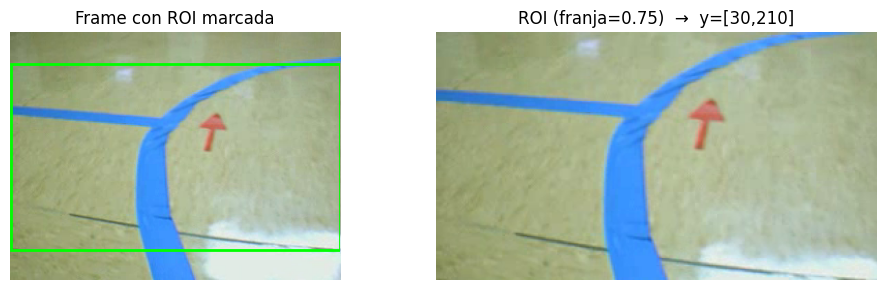

In [34]:
def get_roi(shape, franja=0.75, anticipacion=0.0):
    """
    Franja de tamaño franja (0.75 = 75% del alto) centrada en el punto 
    anticipacion (0.0 = centro, -0.1 = 10% hacia arriba, +0.1 = 10% hacia abajo).
    """
    H, W = shape[:2]
    alto   = int(H * franja)
    centro = H // 2 - int(H * anticipacion)
    y0 = max(0, centro - alto // 2)
    y1 = min(H, y0 + alto)
    return y0, y1, 0, W

def aplicar_roi(arr, roi):
    y0, y1, x0, x1 = roi
    return arr[y0:y1, x0:x1]

roi = get_roi(im.shape)

print('ROI (y0,y1,x0,x1):', roi)
imRoi = aplicar_roi(im, roi)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].imshow(im)
y0_r, y1_r = roi[0], roi[1]
rect = plt.Rectangle((0, y0_r), im.shape[1]-1, y1_r-y0_r,
                       edgecolor='lime', facecolor='none', linewidth=2)
axs[0].add_patch(rect)
axs[0].set_title('Frame con ROI marcada')
axs[0].axis('off')
axs[1].imshow(imRoi)
axs[1].set_title(f'ROI (franja=0.75)  →  y=[{y0_r},{y1_r}]')
axs[1].axis('off')
plt.tight_layout()
plt.show()


In [35]:
RUN_VIDEO_ROI = False

if RUN_VIDEO_ROI:
    video_in  = os.path.join(DIR_VIDEOS, 'video2017-3.avi')
    video_out = 'video_roi.avi'
    MAX_FRAMES = 300  # Número de frames a procesar (None para todo el vídeo)

    cap = cv2.VideoCapture(video_in)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    out_writer = cv2.VideoWriter(video_out, fourcc, fps, (W, H))

    n = 0
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        if MAX_FRAMES is not None and n >= MAX_FRAMES:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        roi = get_roi(frame_rgb.shape)
        y0, y1, x0, x1 = roi

        out_frame = frame_rgb.copy()
        cv2.rectangle(out_frame, (x0, y0), (x1 - 1, y1 - 1), (0, 255, 0), 2)

        out_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
        n += 1

    cap.release()
    out_writer.release()
    print(f'Vídeo generado: {video_out} ({n} frames)')
else:
    print('Pon RUN_VIDEO_ROI = True para generar el vídeo con la ROI marcada.')


Pon RUN_VIDEO_ROI = True para generar el vídeo con la ROI marcada.


## 3. Detección de entradas y salidas de la línea

En la ROI, la línea entra y sale por los bordes del rectángulo. Cada cluster de píxeles de línea sobre el borde del ROI es un endpoint (entrada o salida).

El borde inferior siempre corresponde al lado del robot, así que el endpoint que esté ahí es la entrada. Los demás son salidas.


In [36]:
def runs_in_border(border_pixels):
    """Dado un array binario 1D, devuelve la lista de tuplas (i_inicio, i_fin) de los runs True."""
    runs = []
    n = len(border_pixels)
    i = 0
    while i < n:
        if border_pixels[i]:
            j = i
            while j < n and border_pixels[j]:
                j += 1
            runs.append((i, j-1))
            i = j
        else:
            i += 1
    return runs

def endpoints_en_roi(m_linea, roi):
    """Encuentra los endpoints donde la mascara linea cruza los 4 bordes de la ROI.
    Devuelve lista de dicts: {'side':'top|bottom|left|right', 'pt':(x,y), 'role':'entrada|salida'}."""
    # Defino los 4 bordes de la ROI
    y0, y1, x0, x1 = roi
    # Extraigo la mascara de la línea dentro de la ROI
    sub = m_linea[y0:y1, x0:x1]
    H, W = sub.shape

    # Defino los 4 bordes con su función de conversión a coordenadas globales y rol esperado
    borders = [
        ('bottom', sub[H-1, :], lambda m: (x0 + m, y0 + H - 1), 'entrada'),
        ('top', sub[0, :], lambda m: (x0 + m, y0), 'salida'),
        ('left', sub[:, 0], lambda m: (x0, y0 + m), 'salida'),
        ('right', sub[:, W-1], lambda m: (x0 + W - 1, y0 + m), 'salida'),
    ]

    # Recorro cada borde, encuentro los runs de píxeles True y calculo el punto medio de cada run como endpoint.
    endpoints = []
    for side, pixels, to_pt, role in borders:
        for a, b in runs_in_border(pixels):
            endpoints.append({'side': side, 'pt': to_pt((a + b) // 2), 'role': role})

    # Si no hay endpoint en bottom, el más inferior se convierte en entrada
    if not any(e['role'] == 'entrada' for e in endpoints) and endpoints:
        max(endpoints, key=lambda e: e['pt'][1])['role'] = 'entrada'

    return endpoints


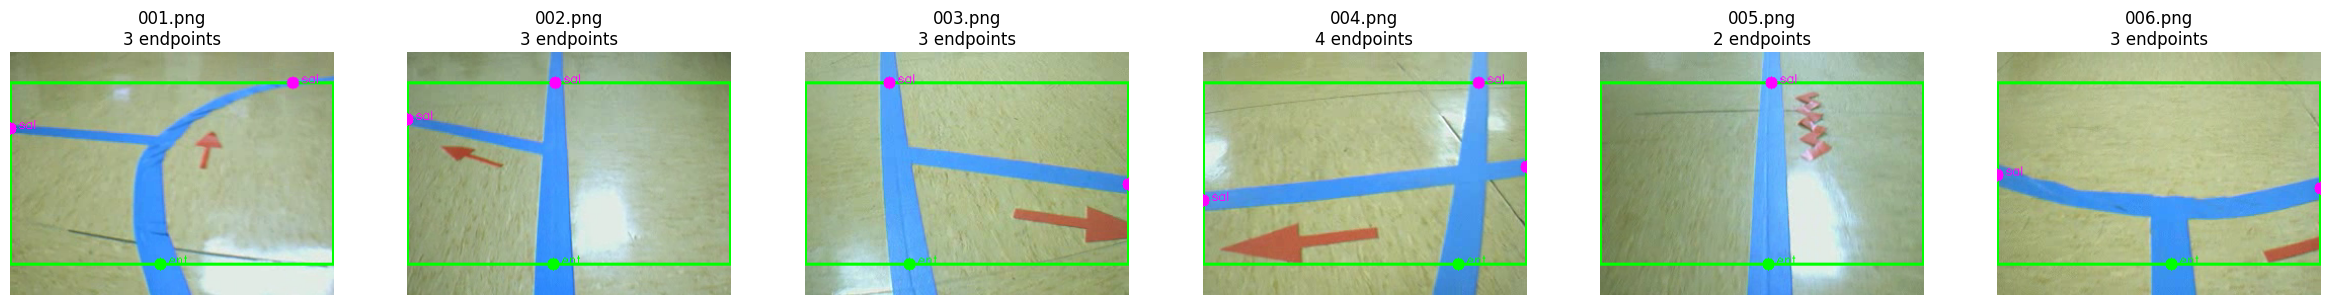

Vídeo generado: video_endpoints.avi (2311 frames)


In [37]:
def dibuja_endpoints(im, endpoints, roi):
    out = im.copy()
    y0, y1, x0, x1 = roi
    cv2.rectangle(out, (x0, y0), (x1-1, y1-1), (0, 255, 0), 2)
    for e in endpoints:
        color = (0, 255, 0) if e['role']=='entrada' else (255, 0, 255)
        cv2.circle(out, e['pt'], 6, color, -1)
        cv2.putText(out, e['role'][:3], (e['pt'][0]+8, e['pt'][1]), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return out

def genera_video_endpoints(video_in, video_out, clf):
    """Procesa el vídeo completo y guarda uno nuevo con los endpoints anotados."""
    cap = cv2.VideoCapture(video_in)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    writer = cv2.VideoWriter(video_out, fourcc, fps, (W, H))

    n = 0
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        lbl = segmentar(frame_rgb, clf)
        m_l, _ = mascaras(lbl)
        roi = get_roi(frame_rgb.shape)
        eps = endpoints_en_roi(m_l, roi)
        anot = dibuja_endpoints(frame_rgb, eps, roi)
        writer.write(cv2.cvtColor(anot, cv2.COLOR_RGB2BGR))
        n += 1

    cap.release()
    writer.release()
    print(f'Vídeo generado: {video_out} ({n} frames)')

# Ejemplo con los 6 frames de prueba
fig, axs = plt.subplots(1, 6, figsize=(24, 3))
for i, f in enumerate(['001.png','002.png','003.png','004.png','005.png','006.png']):
    img = iio.imread(os.path.join(DIR_ETIQ, f))[:, :, :3]
    lbl = segmentar(img, clf)
    m_l, _ = mascaras(lbl)
    eps = endpoints_en_roi(m_l, get_roi(img.shape))
    axs[i].imshow(dibuja_endpoints(img, eps, get_roi(img.shape)))
    axs[i].set_title(f'{f}\n{len(eps)} endpoints')
    axs[i].axis('off')
plt.tight_layout()
plt.show()

genera_video_endpoints(os.path.join(DIR_VIDEOS, 'video2017-4.avi'), 'video_endpoints.avi', clf)


## 4. Clasificación de la escena

| nº endpoints | escena                          |
|--------------|---------------------------------|
| 2            | línea recta o curva (izda/dcha) |
| 3            | cruce con 2 salidas (Y o T)     |
| ≥ 4          | cruce con 3 salidas (X)         |

Para 2 endpoints, distinguimos recta de curva comparando la coordenada X de la entrada (borde inferior) con la de la salida.
Si la diferencia es pequeña, es recta, si no, curva izquierda o derecha según hacia qué lado se desplaza la salida.

In [38]:
def clasifica_escena(endpoints, umbral_curvatura=10):
    """Devuelve la etiqueta de escena y, para curvas, el sentido."""
    n = len(endpoints)

    # Con 4 o más endpoints hay 3 salidas posibles -> cruce en X
    if n >= 4:
        return 'cruce 3 salidas'

    # Con 3 endpoints hay 2 salidas posibles -> cruce en Y o T
    if n == 3:
        return 'cruce 2 salidas'

    if n < 2:
        return 'escena no clara'

    e_in  = next((e for e in endpoints if e['role'] == 'entrada'), None)
    e_out = next((e for e in endpoints if e['role'] == 'salida'), None)

    # Si no hay entrada y salida diferenciadas, asumimos línea recta
    if e_in is None or e_out is None:
        return 'linea recta'

    # Comparamos la X del endpoint de entrada (borde inferior, lado del robot) con la X del endpoint de salida (borde superior o lateral).
    # Si están alineados verticalmente (desplazamiento lateral pequeño) -> línea recta.
    # Si la salida está claramente más a la izda/dcha -> curva en ese sentido.
    dx_ie = e_out['pt'][0] - e_in['pt'][0]

    if abs(dx_ie) <= umbral_curvatura:
        return 'linea recta'
    return 'curva izda' if dx_ie < 0 else 'curva dcha'


In [39]:

# Test sobre los 6 frames etiquetados
for f in ['001.png','002.png','003.png','004.png','005.png', '006.png']:
    img = iio.imread(os.path.join(DIR_ETIQ, f))[:, :, :3]
    etiq = segmentar(img, clf)
    mask_linea, _ = mascaras(etiq)
    roi_f = get_roi(img.shape)
    eps = endpoints_en_roi(mask_linea, roi_f)
    escena = clasifica_escena(eps)
    print(f'{f}: {len(eps)} endpoints -> {escena}')


001.png: 3 endpoints -> cruce 2 salidas
002.png: 3 endpoints -> cruce 2 salidas
003.png: 3 endpoints -> cruce 2 salidas
004.png: 4 endpoints -> cruce 3 salidas
005.png: 2 endpoints -> linea recta
006.png: 3 endpoints -> cruce 2 salidas


In [40]:
RUN_VIDEO_ESCENAS = False    # poner a False para saltarse la generación

if RUN_VIDEO_ESCENAS:
    video_in  = os.path.join(DIR_VIDEOS, 'video2017-3.avi')
    video_out = 'video_escenas.avi'

    cap = cv2.VideoCapture(video_in)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    writer = cv2.VideoWriter(video_out, fourcc, fps, (W, H))

    n = 0
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        lbl       = segmentar(frame_rgb, clf)
        m_l, _    = mascaras(lbl)
        roi       = get_roi(frame_rgb.shape)
        eps       = endpoints_en_roi(m_l, roi)
        escena    = clasifica_escena(eps)

        anot = dibuja_endpoints(frame_rgb, eps, roi)
        cv2.putText(anot, f'escena: {escena}', (5, 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

        writer.write(cv2.cvtColor(anot, cv2.COLOR_RGB2BGR))
        n += 1

    cap.release()
    writer.release()
    print(f'Vídeo generado: {video_out} ({n} frames)')
else:
    print('Pon RUN_VIDEO_ESCENAS = True para generar el vídeo.')


Pon RUN_VIDEO_ESCENAS = True para generar el vídeo.


## 5. Salida elegida en cruces

Cuando la escena es un cruce y hay una mancha roja (la flecha) visible en la ROI usamos el algoritmo **momentum of inertia**:

1. Calculamos el **centroide** y el **tensor de inercia** del blob rojo (Ix, Iy, Ixy).
2. **Descenso de gradiente** sobre el ángulo `sita` para hallar el eje principal (máxima elongación).
3. Proyectamos la masa sobre ese eje y sobre el perpendicular, y comparamos la **asimetría** entre semiplanos: el lado con **menor momento** es la punta triangular (más estrecha).
4. Elegimos la salida del cruce cuya dirección desde el centroide forma el **menor ángulo** con el vector centroide → punta.


In [41]:
def orientacion_flecha(m_marca_roi, area_min=30):
    """Detecta la orientacion de la flecha mediante el tensor de inercia.

    Algoritmo momentum_of_inertia:
    1. Centroide y tensor de inercia (Ix, Iy, Ixy) del blob.
    2. Descenso de gradiente para hallar el eje principal (angulo de maxima elongacion).
    3. Asimetria de masa en cada semiplano: el lado con MENOR momento es la punta
       (triangular = masa mas concentrada hacia un punto).

    Devuelve (cx, cy, tx, ty) en coords de la ROI, o None si no hay flecha valida.
    """
    A = m_marca_roi.astype(np.float64)
    total = A.sum()
    if total < area_min:
        return None

    rows, cols = A.shape
    XX, YY = np.meshgrid(np.arange(cols, dtype=np.float64),
                         np.arange(rows, dtype=np.float64))

    # Centroide
    cx = (XX * A).sum() / total
    cy = (YY * A).sum() / total
    dx = XX - cx
    dy = YY - cy

    # Tensor de inercia normalizado
    Ix  = (dy**2 * A).sum() / total
    Iy  = (dx**2 * A).sum() / total
    Ixy = (dx * dy * A).sum() / total

    # Descenso de gradiente para hallar el eje principal
    sita = 0.0
    for _ in range(1000):
        tangent = -np.sin(2*sita)*Ix + np.sin(2*sita)*Iy - 2*np.cos(2*sita)*Ixy
        sita -= 0.02 * tangent

    # Asimetria a lo largo del eje principal
    proj_main = (np.cos(sita)*dx + np.sin(sita)*dy) * A / total
    I_p = (proj_main[proj_main > 0]**2).sum()
    I_n = (proj_main[proj_main < 0]**2).sum()

    # Asimetria a lo largo del eje perpendicular
    proj_perp = (np.cos(sita + np.pi/2)*dx + np.sin(sita + np.pi/2)*dy) * A / total
    O_p = (proj_perp[proj_perp > 0]**2).sum()
    O_n = (proj_perp[proj_perp < 0]**2).sum()

    # El lado con MENOR momento es la punta (mas estrecha)
    if abs(I_p - I_n) >= abs(O_p - O_n):
        angle = sita if I_p < I_n else sita + np.pi
    else:
        angle = (sita + np.pi/2) if O_p < O_n else (sita + 3*np.pi/2)

    # Punto de la punta: pixel del blob mas alejado en la direccion angle
    py_idx, px_idx = np.where(A > 0)   # py_idx=filas, px_idx=columnas
    proj_tip = (px_idx - cx)*np.cos(angle) + (py_idx - cy)*np.sin(angle)
    tip = np.argmax(proj_tip)
    tx, ty = float(px_idx[tip]), float(py_idx[tip])

    return float(cx), float(cy), float(tx), float(ty)


def salida_elegida(arrow_info, endpoints, roi):
    """Salida cuya direccion desde el centroide forma menor angulo con centroide->punta."""
    if arrow_info is None:
        return None
    y0, y1, x0, x1 = roi
    cx, cy, tx, ty = arrow_info

    vx, vy = tx - cx, ty - cy
    n_v = np.hypot(vx, vy)
    if n_v < 1e-6:
        return None
    vx, vy = vx / n_v, vy / n_v

    cx_g, cy_g = cx + x0, cy + y0
    salidas = [e for e in endpoints if e['role'] == 'salida']
    if not salidas:
        return None

    def cos_ang(s):
        sx, sy = s['pt']
        dx, dy = sx - cx_g, sy - cy_g
        n = np.hypot(dx, dy)
        if n < 1e-6:
            return -2.0
        return (dx * vx + dy * vy) / n

    return max(salidas, key=cos_ang)


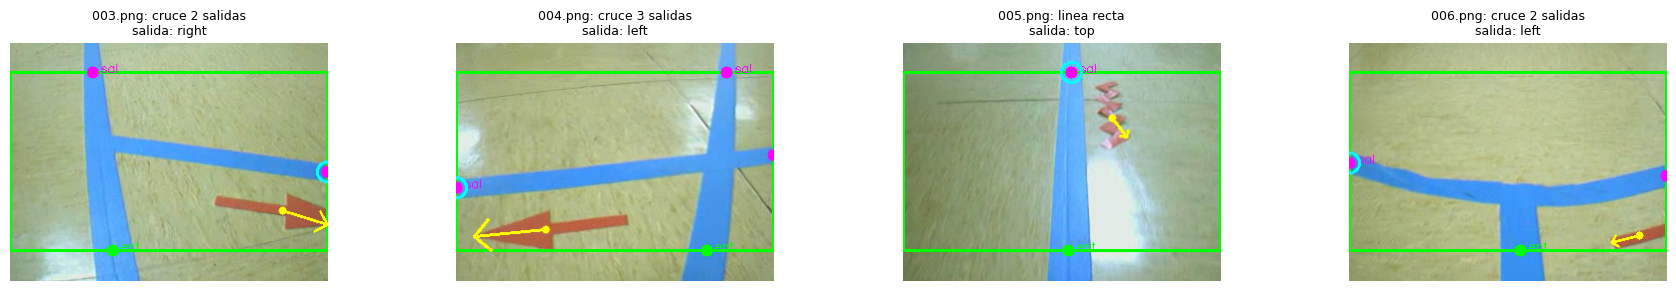

In [42]:

def dibuja_flecha(im, arrow_info, roi):
    """Dibuja la flecha estimada: linea con punta desde el centroide hasta la punta detectada."""
    out = im.copy()
    if arrow_info is None:
        return out
    y0, y1, x0, x1 = roi
    cx, cy, tx, ty = arrow_info
    p_centro = (int(cx + x0), int(cy + y0))
    p_punta  = (int(tx + x0), int(ty + y0))
    cv2.arrowedLine(out, p_centro, p_punta, (255, 255, 0), 2, tipLength=0.3)
    cv2.circle(out, p_centro, 4, (255, 255, 0), -1)
    return out

# Ejemplos: Frames con flecha (y uno sin ella)
frames_demo = ['003.png','004.png','005.png','006.png']
fig, axs = plt.subplots(1, 4, figsize=(18, 3))
for ax, f in zip(axs, frames_demo):
    img = iio.imread(os.path.join(DIR_ETIQ, f))[:, :, :3]
    etiq = segmentar(img, clf)
    mask_linea, mask_marca = mascaras(etiq)
    roi_f = get_roi(img.shape)
    eps   = endpoints_en_roi(mask_linea, roi_f)
    m_m_roi = aplicar_roi(mask_marca, roi_f)
    info = orientacion_flecha(m_m_roi)
    sel = salida_elegida(info, eps, roi_f)

    out = dibuja_endpoints(img, eps, roi_f)
    out = dibuja_flecha(out, info, roi_f)
    if sel is not None:
        cv2.circle(out, sel['pt'], 10, (0, 255, 255), 2)

    titulo = f'{f}: {clasifica_escena(eps)}'
    if sel is not None:
        titulo += f'\nsalida: {sel["side"]}'
    ax.imshow(out); ax.axis('off'); ax.set_title(titulo, fontsize=9)
plt.tight_layout()
plt.show()


## 6. Estimación del Error de Seguimiento.

El error de seguimiento es la diferencia entre el centro de la línea y el centro de la imagen.

In [43]:
def error_seguimiento(m_linea, roi, alto_franja=15):
    H, W = m_linea.shape
    _, y_roi_bot, _, _ = roi
    y_centro = min(y_roi_bot, H - 1)
    y0 = max(0, y_centro - alto_franja)
    y1 = min(H, y_centro)

    franja = m_linea[y0:y1, :]
    ys, xs = np.where(franja)
    if len(xs) < 5:
        return None, None, W // 2

    x_linea = xs.mean()
    x_centro = W / 2.0
    return x_linea - x_centro, x_linea, x_centro

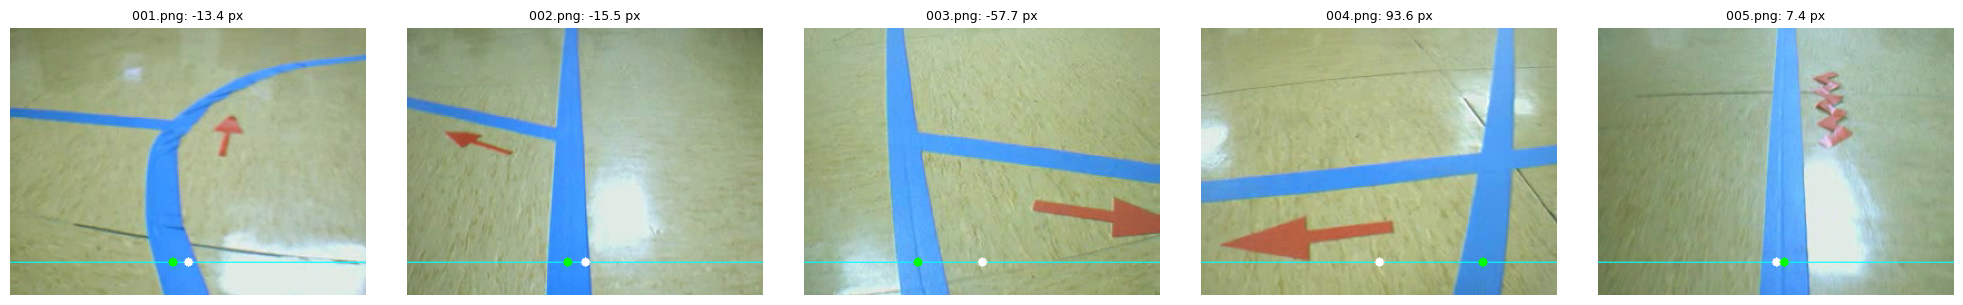

In [44]:
# Test: pinta los dos puntos (centro imagen y centro línea) y el error en píxeles sobre cada frame de prueba.
fig, axs = plt.subplots(1, 5, figsize=(20, 3))
for ax, f in zip(axs, ['001.png','002.png','003.png','004.png','005.png']):
    img = iio.imread(os.path.join(DIR_ETIQ, f))[:, :, :3]
    lbl = segmentar(img, clf)
    m_l, _ = mascaras(lbl)
    H, W = m_l.shape
    roi_f = get_roi(img.shape)
    err, x_l, x_c = error_seguimiento(m_l, roi_f)

    out = img.copy()
    yf = roi_f[1]
    cv2.line(out, (0, yf), (W, yf), (0, 255, 255), 1)
    cv2.circle(out, (int(x_c), yf), 4, (255, 255, 255), -1)
    if x_l is not None:
        cv2.circle(out, (int(x_l), yf), 4, (0, 255, 0), -1)

    titulo = f'{f}: {err:.1f} px' if err is not None else f'{f}: sin linea'
    ax.imshow(out); ax.axis('off'); ax.set_title(titulo, fontsize=9)
plt.tight_layout()
plt.show()


## 7. Cálculo de la consigna de control



In [45]:
class ControladorVisual:
    """Controlador PD como el de BrainFollowLine"""
    KP      = 0.9
    KD      = 0.5
    V_MAX   = 0.4
    V_MIN   = 0.05

    def __init__(self):
        self.err_prev = 0.0

    def consigna(self, escena, error, error_cruce=None, W=320):
        if not any(k in escena for k in ('recta', 'curva', 'cruce')):
            return 0.0, 0.0

        # Error en píxeles: en cruce usamos el error hacia la salida elegida
        e_px = (error_cruce if ('cruce' in escena and error_cruce is not None)
                else (error if error is not None else 0.0))

        # Normalizamos a [-1, 1] igual que BrainFollowLine
        e = e_px / (W / 2)
        e = max(-1.0, min(1.0, e))

        de = e - self.err_prev
        omega = -(self.KP * e + self.KD * de)
        omega = max(-1.0, min(1.0, omega))

        # La velocidad baja cuando el giro es grande (mismo cálculo que BrainFollowLine)
        v = max(self.V_MIN, self.V_MAX - abs(omega) * 1.5 * self.V_MAX)

        self.err_prev = e
        return v, omega


## 8. Pipeline completo y demostración por frame

Reunimos todo en una única función `analizar_frame` que toma un frame BGR (como los devuelve `cv2.VideoCapture`) y devuelve un diccionario con todo lo necesario para el control y para anotar el frame de salida.


In [46]:
def analizar_frame(frame_rgb, clf, controlador):
    """Pipeline completo: segmenta, detecta endpoints, clasifica, busca flecha,
       calcula error y consigna."""
    roi = get_roi(frame_rgb.shape)
    labels = segmentar(frame_rgb, clf)
    m_l, m_m = mascaras(labels)

    eps    = endpoints_en_roi(m_l, roi)
    escena = clasifica_escena(eps)
    err, _, x_c = error_seguimiento(m_l, roi)

    # Si es cruce y hay flecha, calculamos error hacia la salida elegida
    err_cruce = None
    info_flecha = None
    salida = None
    if 'cruce' in escena:
        m_m_roi = aplicar_roi(m_m, roi)
        info_flecha = orientacion_flecha(m_m_roi)
        salida = salida_elegida(info_flecha, eps, roi)
        if salida is not None:
            err_cruce = salida['pt'][0] - x_c

    v, omega = controlador.consigna(escena, err, err_cruce)

    return {
        'roi': roi,
        'm_linea': m_l,
        'm_marca': m_m,
        'endpoints': eps,
        'escena': escena,
        'flecha': info_flecha,
        'salida_elegida': salida,
        'error_seguimiento': err,
        'error_cruce': err_cruce,
        'v': v,
        'omega': omega,
    }


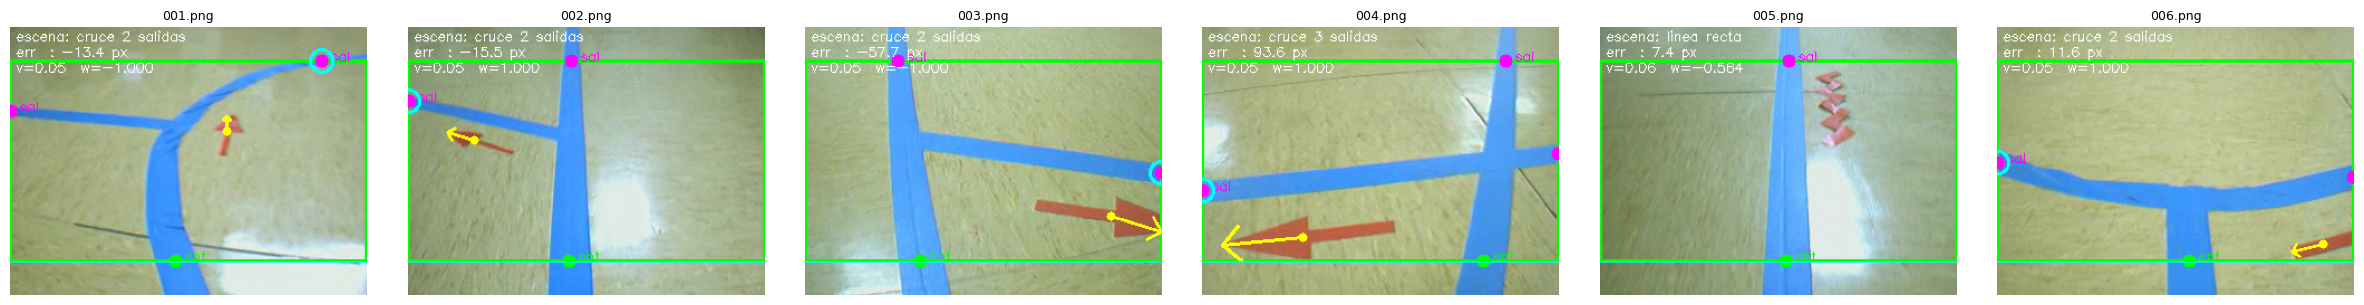

In [47]:
def anota_frame(frame_rgb, info):
    """Devuelve el frame con todas las anotaciones encima."""
    out = dibuja_endpoints(frame_rgb, info['endpoints'], info['roi'])
    out = dibuja_flecha(out, info['flecha'], info['roi'])

    if info['salida_elegida'] is not None:
        cv2.circle(out, info['salida_elegida']['pt'], 10, (0, 255, 255), 2)

    H, W = out.shape[:2]
    yf = info['roi'][1]
    cv2.line(out, (0, yf), (W, yf), (0, 255, 255), 1)

    txt = [
        f"escena: {info['escena']}",
        f"err  : {info['error_seguimiento']:.1f} px" if info['error_seguimiento'] is not None else 'err  : -',
        f"v={info['v']:.2f}  w={info['omega']:.3f}",
    ]
    for i, t in enumerate(txt):
        cv2.putText(out, t, (5, 12 + 14*i), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
    return out

# Demo en los 5 frames etiquetados
ctrl = ControladorVisual()
fig, axs = plt.subplots(1, 6, figsize=(24, 3))
for i, f in enumerate(['001.png','002.png','003.png','004.png','005.png', '006.png']):
    img = iio.imread(os.path.join(DIR_ETIQ, f))[:, :, :3]
    info = analizar_frame(img, clf, ctrl)
    axs[i].imshow(anota_frame(img, info))
    axs[i].set_title(f, fontsize=9); axs[i].axis('off')
plt.tight_layout()
plt.show()


## 9. Validación sobre frames del vídeo

Procesamos algunos frames muestreados de video2017-4.avi para validar el pipeline en escenas que no hemos visto durante el etiquetado.


In [48]:
from datetime import datetime
def muestrear_video(path, n=8):
    """Devuelve n frames RGB equiespaciados a lo largo del video."""
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print('No se abre', path); return []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    inicio = int(total * 0.05)   # salta los primeros fotogramas en negro
    idxs = np.linspace(inicio, total - 1, n * 2).astype(int)
    out = []
    t1 = datetime.now()
    tiempos = []
    for k in idxs:
        t1 = datetime.now()
        print(t1.strftime('%H:%M:%S'), f'Procesando frame {k}... ', end='')
        if len(out) >= n:
            break
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(k))
        ret, frame = cap.read()
        if ret:
            out.append((int(k), cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        t2 = datetime.now()
        tiempos.append((t2 - t1).total_seconds())
        print(f'hecho en {tiempos[-1]:.2f} s')
    cap.release()
    print(f'Tiempo medio por frame: {np.mean(tiempos):.2f} s')
    return out

frames = muestrear_video(os.path.join(DIR_VIDEOS, 'video2017-3.avi'), n=8)
print(f'Muestreados {len(frames)} frames')


17:27:06 Procesando frame 144... hecho en 0.03 s
17:27:06 Procesando frame 326... hecho en 0.01 s
17:27:06 Procesando frame 509... hecho en 0.03 s
17:27:06 Procesando frame 692... hecho en 0.02 s
17:27:06 Procesando frame 875... hecho en 0.01 s
17:27:06 Procesando frame 1058... hecho en 0.01 s
17:27:06 Procesando frame 1241... hecho en 0.02 s
17:27:06 Procesando frame 1424... hecho en 0.02 s
17:27:06 Procesando frame 1607... Tiempo medio por frame: 0.02 s
Muestreados 8 frames


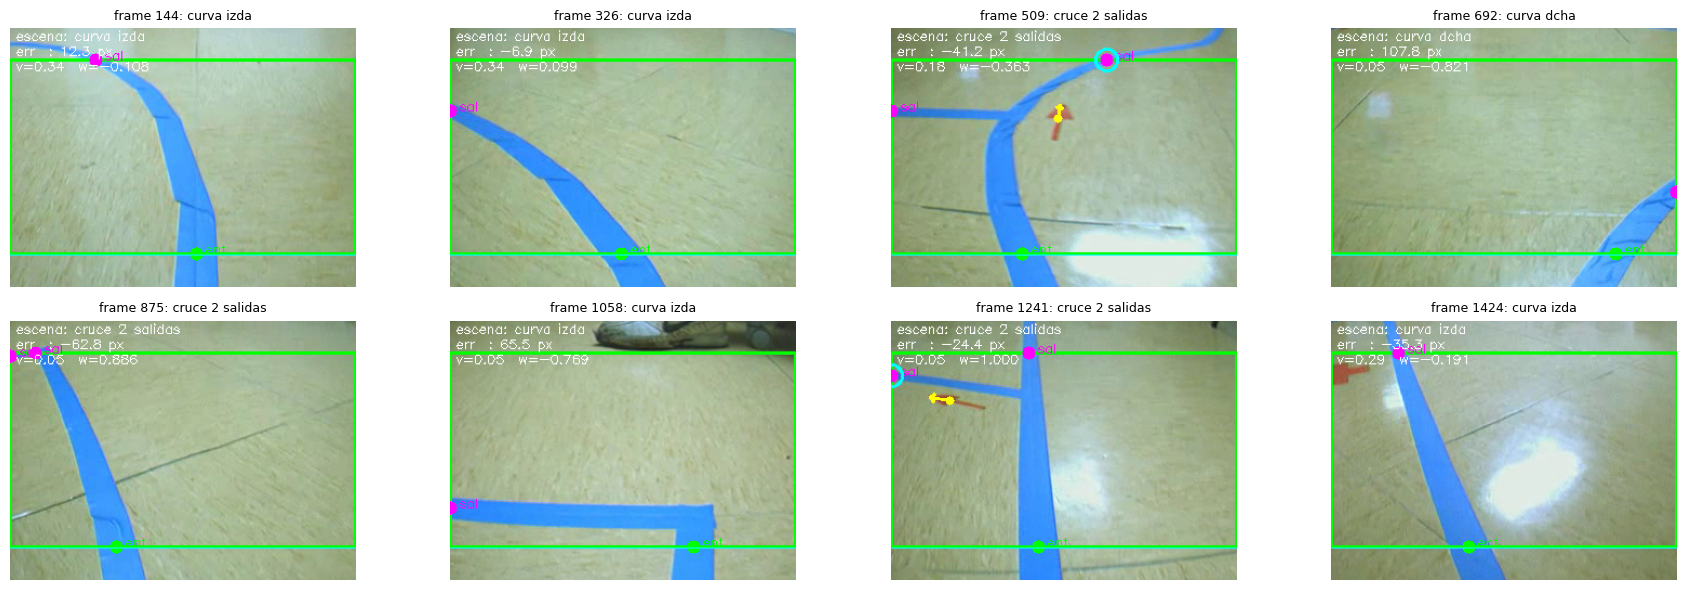

In [49]:
ctrl = ControladorVisual()
fig, axs = plt.subplots(2, 4, figsize=(18, 6))
for ax, (k, frame) in zip(axs.flat, frames):
    info = analizar_frame(frame, clf, ctrl)
    ax.imshow(anota_frame(frame, info))
    ax.set_title(f'frame {k}: {info["escena"]}', fontsize=9)
    ax.axis('off')
for ax in axs.flat:
    if not ax.images:
        ax.axis('off')

plt.tight_layout()
plt.show()

## 10. Generación del vídeo anotado

El siguiente bloque procesa el vídeo completo y guarda otro vídeo con todas las anotaciones encima (escena, error, consigna).


In [ ]:
RUN_VIDEO = False    # poner a True para generar el video

if RUN_VIDEO:
    video_in  = os.path.join(DIR_VIDEOS, 'video2017-3.avi')
    video_out = 'video_analizado_2017-3.avi'

    cap = cv2.VideoCapture(video_in)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    out_writer = cv2.VideoWriter(video_out, fourcc, fps, (W, H))
    ctrl = ControladorVisual()

    n = 0
    t1 = datetime.now()
    tiempos = []
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        info = analizar_frame(frame_rgb, clf, ctrl)
        anot = anota_frame(frame_rgb, info)
        out_writer.write(cv2.cvtColor(anot, cv2.COLOR_RGB2BGR))
        n += 1
        t2 = datetime.now()
        tiempos.append((t2 - t1).total_seconds())
        t1 = t2
    cap.release(); out_writer.release()
    print(f'Video generado: {video_out} ({n} frames)')
    print(f'Tiempo medio por frame: {np.mean(tiempos):.2f} s')
else:
    print('Pon RUN_VIDEO = True para generar el video anotado.')



Video generado: video_analizado_2017-3.avi (2887 frames)
Tiempo medio por frame: 0.02 s


## 11. Clasificación de marcas (Hu Moments + KNN)

Construimos un clasificador de marcas (escalera, hombre, mujer, teléfono) usando los 7 Momentos de Hu como descriptor de forma, invariantes a traslación, rotación y escala.

**Pipeline de extracción del descriptor:**
1. Binarizar la imagen de la marca (segmentación por color).
2. Quedarse con el contorno más grande (`extraer_marca_binaria`).
3. Normalizamos la silueta: recortamos y redimensionar a 100×100 px (`normalizar_marca`). Esto elimina los errores debidos al tamaño de la región.
4. Calcular los 7 Momentos de Hu y aplicar la transformación logarítmica estándar:

$$h'_i = -\text{sign}(h_i)\cdot\log_{10}(|h_i|)$$

El clasificador es KNeighborsClassifier (Clasificador de K vecinos) con (k=3), entrenado con las imágenes de `images/marcas/<clase>/`. Se evalúa sobre el propio conjunto de entrenamiento (matriz de confusión + accuracy) y sobre frames muestreados del vídeo.


In [51]:
def extraer_marca_binaria(mask_marca, area_min=50):
    """
    Recibe máscara booleana o uint8 de la región de marca.
    Devuelve imagen uint8 (0/255) con solo el contorno más grande relleno, o None
    si no hay contornos o el mayor no supera area_min píxeles.
    """
    m = (mask_marca > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None
    cont = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cont) < area_min:
        return None
    clean = np.zeros_like(m)
    cv2.drawContours(clean, [cont], -1, 255, -1)
    return clean


def normalizar_marca(img_bin, size=100):
    """
    Recorta al bounding box de la máscara y redimensiona a sizexsize.
    Devuelve la imagen normalizada (uint8 0/255), o None si la máscara está vacía.
    """
    ys, xs = np.where(img_bin > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    recorte = img_bin[ys.min():ys.max()+1, xs.min():xs.max()+1]
    return cv2.resize(recorte, (size, size))


In [52]:
EXTS_IMG   = {'.png', '.jpg', '.jpeg', '.bmp'}
DIR_MARCAS = os.path.join('..', 'images', 'marcas')

def hu_descriptor(img_bin):
    """
    Descriptor de Hu (7 valores) con transformación logarítmica estándar:
        h'_i = -sign(h_i) * log10(|h_i|)
    Invariante a traslación, rotación y escala.
    """
    moments = cv2.moments(img_bin, binaryImage=True)
    hu = cv2.HuMoments(moments).flatten()
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)


def binarizar_imagen_marca(img):
    """
    Devuelve máscara uint8 (0/255) de la región de marca en una imagen.
    - Si es RGB: usa el segmentador de color (clase 0 = marca).
    - Si es escala de grises / binaria: umbral fijo en 127.
    """
    if img.ndim == 3:
        img3 = img[:, :, :3]
        etiq = segmentar(img3, clf)
        mask = (etiq == 0).astype(np.uint8) * 255
        if mask.sum() > 0:
            return mask
        return mask
    else:
        _, mask = cv2.threshold(img.astype(np.uint8), 127, 255, cv2.THRESH_BINARY)
        return mask


def cargar_dataset_marcas(dir_marcas):
    """
    Recorre cada subcarpeta de dir_marcas (nombre de subcarpeta = clase),
    carga las imágenes, binariza y extrae el descriptor de Hu de cada una.

    Devuelve:
        X      -- array (N, 7) de descriptores Hu
        y      -- array (N,) de etiquetas enteras
        clases -- lista de nombres de clase (índice = valor de y)
    """
    clase_dirs = sorted(p for p in Path(dir_marcas).iterdir() if p.is_dir())
    clases = [d.name for d in clase_dirs]
    X, y = [], []
    for idx, clase_dir in enumerate(clase_dirs):
        n_ok = 0
        for img_path in sorted(clase_dir.iterdir()):
            if img_path.suffix.lower() not in EXTS_IMG:
                continue
            img = iio.imread(str(img_path))
            mask = binarizar_imagen_marca(img)
            limpia = extraer_marca_binaria(mask)
            if limpia is not None:
                limpia = normalizar_marca(limpia)
            if limpia is None:
                print(f'  [AVISO] sin contorno válido en {img_path.name}')
                continue
            limpia = cv2.medianBlur(limpia, 5)
            X.append(hu_descriptor(limpia))
            y.append(idx)
            n_ok += 1
        print(f'  {clase_dir.name}: {n_ok} imágenes cargadas')
    if X:
        return np.array(X), np.array(y), clases
    return np.empty((0, 7)), np.empty(0, dtype=int), clases


In [53]:
print('Cargando dataset de marcas...')
X_marcas, y_marcas, clases_marcas = cargar_dataset_marcas(DIR_MARCAS)

if len(X_marcas) > 0:
    clf_marcas = KNeighborsClassifier(n_neighbors=3)
    clf_marcas.fit(X_marcas, y_marcas)
    print(f'Clasificador entrenado: {len(X_marcas)} muestras, {len(clases_marcas)} clases')
    print(f'Clases: {clases_marcas}')
else:
    clf_marcas = None
    print('AVISO: No hay imágenes en images/marcas/. Añade imágenes por clase y vuelve a ejecutar.')


Cargando dataset de marcas...


  escalera: 7 imágenes cargadas
  hombre: 7 imágenes cargadas
  mujer: 7 imágenes cargadas
  telefono: 7 imágenes cargadas
Clasificador entrenado: 28 muestras, 4 clases
Clases: ['escalera', 'hombre', 'mujer', 'telefono']


Accuracy (train): 82.1%

              precision    recall  f1-score   support

    escalera       1.00      0.71      0.83         7
      hombre       0.86      0.86      0.86         7
       mujer       0.75      0.86      0.80         7
    telefono       0.75      0.86      0.80         7

    accuracy                           0.82        28
   macro avg       0.84      0.82      0.82        28
weighted avg       0.84      0.82      0.82        28



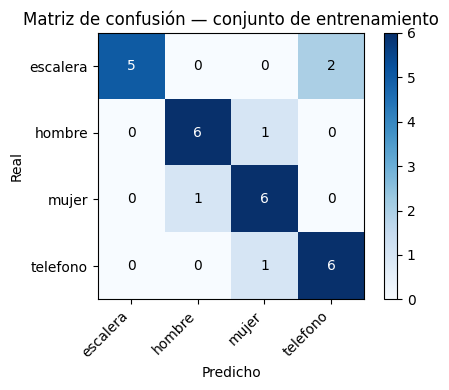

In [54]:
# --- Evaluación sobre el conjunto de entrenamiento ---
if clf_marcas is not None:
    y_pred_train = clf_marcas.predict(X_marcas)
    acc = (y_pred_train == y_marcas).mean()
    print(f'Accuracy (train): {acc * 100:.1f}%\n')
    print(classification_report(y_marcas, y_pred_train, target_names=clases_marcas))

    cm = confusion_matrix(y_marcas, y_pred_train)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(clases_marcas)))
    ax.set_xticklabels(clases_marcas, rotation=45, ha='right')
    ax.set_yticks(range(len(clases_marcas)))
    ax.set_yticklabels(clases_marcas)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title('Matriz de confusión — conjunto de entrenamiento')
    for i in range(len(clases_marcas)):
        for j in range(len(clases_marcas)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print('Sin clasificador — añade imágenes a images/marcas/ y ejecuta la celda anterior.')

## 12. Clasificación de marcas en vídeo

In [55]:
VIDEO_MARCAS_IN  = os.path.join(DIR_VIDEOS, 'video_marcas.avi')
VIDEO_MARCAS_OUT = os.path.join(DIR_VIDEOS, 'video_marcas_anotado.avi')

if clf_marcas is None:
    print('AVISO: clf_marcas no está entrenado. Ejecuta primero la celda de carga del dataset.')
else:
    cap_m = cv2.VideoCapture(VIDEO_MARCAS_IN)
    if not cap_m.isOpened():
        print(f'No se puede abrir: {VIDEO_MARCAS_IN}')
    else:
        fps_m = cap_m.get(cv2.CAP_PROP_FPS) or 25
        W_m   = int(cap_m.get(cv2.CAP_PROP_FRAME_WIDTH))
        H_m   = int(cap_m.get(cv2.CAP_PROP_FRAME_HEIGHT))
        N_m   = int(cap_m.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f'Vídeo: {W_m}x{H_m}  {fps_m:.1f} fps  {N_m} frames')

        fourcc_m = cv2.VideoWriter_fourcc(*'MJPG')
        writer_m = cv2.VideoWriter(VIDEO_MARCAS_OUT, fourcc_m, fps_m, (W_m, H_m))

        etiquetas_video = []
        n_frame = 0

        while True:
            ret, frame_bgr = cap_m.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            vis       = frame_rgb.copy()

            # Clasificación de marcas:
            mask   = binarizar_imagen_marca(frame_rgb)
            limpia = extraer_marca_binaria(mask)
            label  = '—'

            if limpia is not None:
                norm = normalizar_marca(limpia)
                if norm is not None:
                    norm  = cv2.medianBlur(norm, 5)
                    hu    = hu_descriptor(norm)
                    pred  = clf_marcas.predict([hu])[0]
                    label = clases_marcas[pred]

                    # Bounding box de la región de marca
                    ys_bb, xs_bb = np.where(mask > 0)
                    if len(xs_bb):
                        cv2.rectangle(vis,
                                      (xs_bb.min(), ys_bb.min()),
                                      (xs_bb.max(), ys_bb.max()),
                                      (0, 255, 0), 2)

            etiquetas_video.append(label)

            # Anotación del frame
            color_txt = (0, 255, 0) if label != '—' else (0, 0, 255)
            cv2.putText(vis, f'Marca: {label}',
                        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color_txt, 2)
            cv2.putText(vis, f'Frame: {n_frame}',
                        (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)

            writer_m.write(cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
            n_frame += 1

        cap_m.release()
        writer_m.release()
        print(f'Procesados {n_frame} frames  ->  {VIDEO_MARCAS_OUT}')

Vídeo: 320x240  15.0 fps  816 frames


Procesados 816 frames  ->  ..\videos\video_marcas_anotado.avi
